## 画图

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

# 加载 BERT 嵌入向量文件
emb_file = 'data/emb_bert-base-uncased_wiki1m_for_simcse.npy'
emb = np.load(emb_file)

# 使用PCA降维
pca = PCA(n_components=2)  # 降到2维
emb_pca = pca.fit_transform(emb)

# 将降维后的数据转化为 DataFrame，方便绘图
df = pd.DataFrame(emb_pca, columns=['PCA1', 'PCA2'])

# 绘制散点图
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', data=df, s=10, color='blue')
plt.title("PCA of BERT Embeddings", fontsize=15)
plt.xlabel("PCA1", fontsize=12)
plt.ylabel("PCA2", fontsize=12)
plt.show()

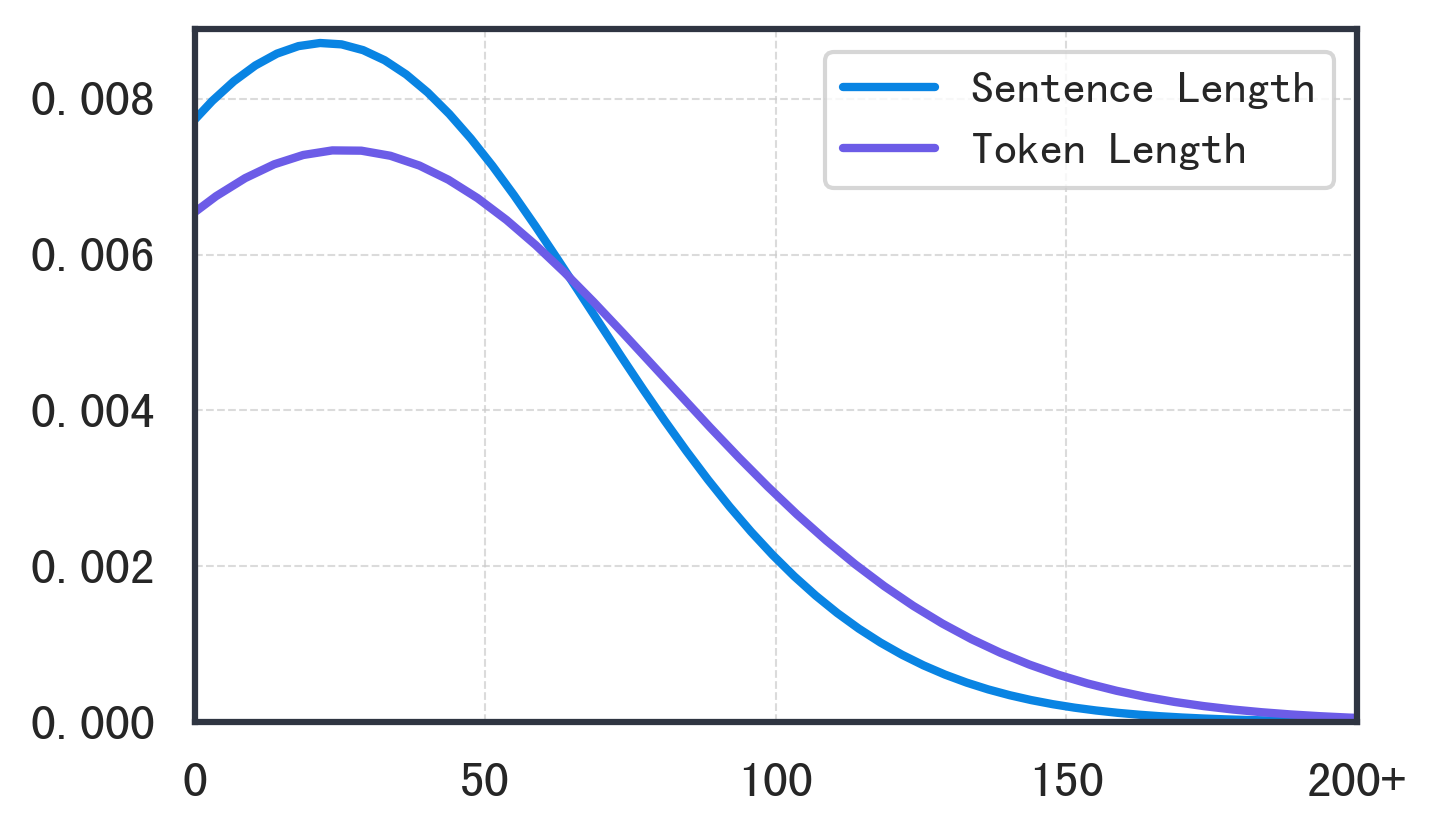

In [ ]:
# c4-绘制句子长度和token长度的密度图
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator, FuncFormatter

# 设置全局样式参数
sns.set(style="whitegrid", font="SimHei")  # 设置网格背景和中文字体

# 加载数据
sent_length_list = np.load('draw-data/c4-句子长度数组.npy')
sent_token_length_list = np.load('draw-data/c4-句子token长度数组.npy')

# 创建图形对象
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

# 绘制句子长度的密度图
sns.kdeplot(sent_length_list, color='#0984e3', lw=2, ax=ax, label="Sentence Length", bw_adjust=50)  # 蓝色

# 绘制token长度的密度图
sns.kdeplot(sent_token_length_list, color='#6c5ce7', lw=2, ax=ax, label="Token Length", bw_adjust=50)  # 紫色

# 设置坐标轴属性
ax.set(xlabel='', ylabel='', xmargin=0, ymargin=0.02)
ax.tick_params(axis='both', labelsize=12)

# 限制x轴范围
ax.set_xlim(0, 200)

# 自定义x轴刻度标签
def format_func(value, tick_number):
    if value == 200:
        return '200+'
    return str(int(value))

ax.xaxis.set_major_formatter(FuncFormatter(format_func))

# 增强边框显示
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set(color='#2f3542', linewidth=1.5)

# 设置网格样式
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# 显示图例
ax.legend()

# 显示图形
plt.show()

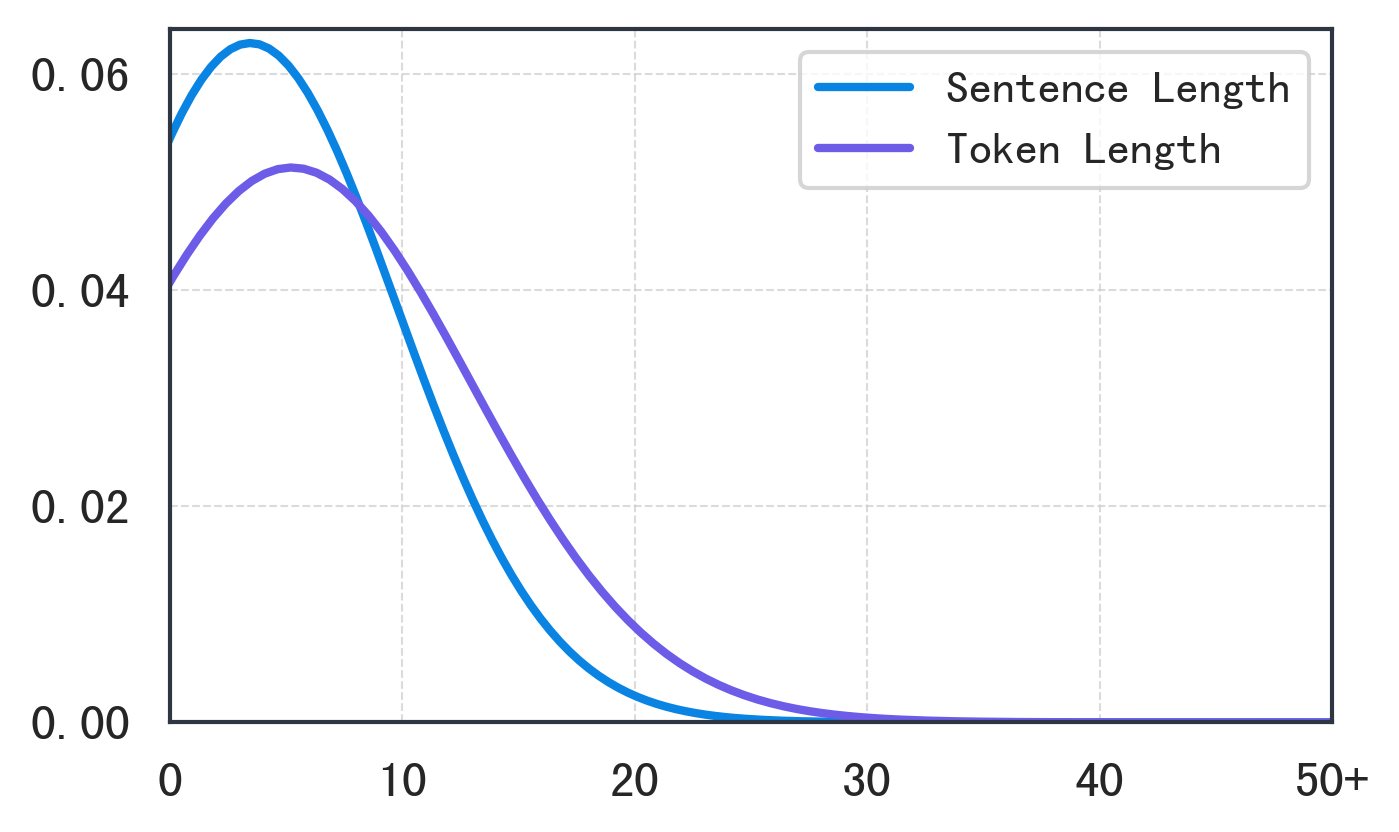

In [ ]:
# c4-绘制句子长度和token长度的密度图
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator, FuncFormatter

# 设置全局样式参数
sns.set(style="whitegrid", font="SimHei")  # 设置网格背景和中文字体

# 加载数据
sent_length_list = np.load('draw-data/f-c4-title句子长度数组.npy')
sent_token_length_list = np.load('draw-data/f-c4-title句子token长度数组.npy')

# 创建图形对象
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

# 绘制句子长度的密度图
sns.kdeplot(sent_length_list, color='#0984e3', lw=2, ax=ax, label="Sentence Length", bw_adjust=50)  # 蓝色

# 绘制token长度的密度图
sns.kdeplot(sent_token_length_list, color='#6c5ce7', lw=2, ax=ax, label="Token Length", bw_adjust=50)  # 紫色

# 设置坐标轴属性
ax.set(xlabel='', ylabel='', xmargin=0, ymargin=0.02)
ax.tick_params(axis='both', labelsize=12)

# 限制x轴范围
ax.set_xlim(0, 50)

# 自定义x轴刻度标签
def format_func(value, tick_number):
    if value == 50:
        return '50+'
    return str(int(value))

ax.xaxis.set_major_formatter(FuncFormatter(format_func))

# 增强边框显示
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set(color='#2f3542', linewidth=1)

# 设置网格样式
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# 显示图例
ax.legend()

# 显示图形
plt.show()

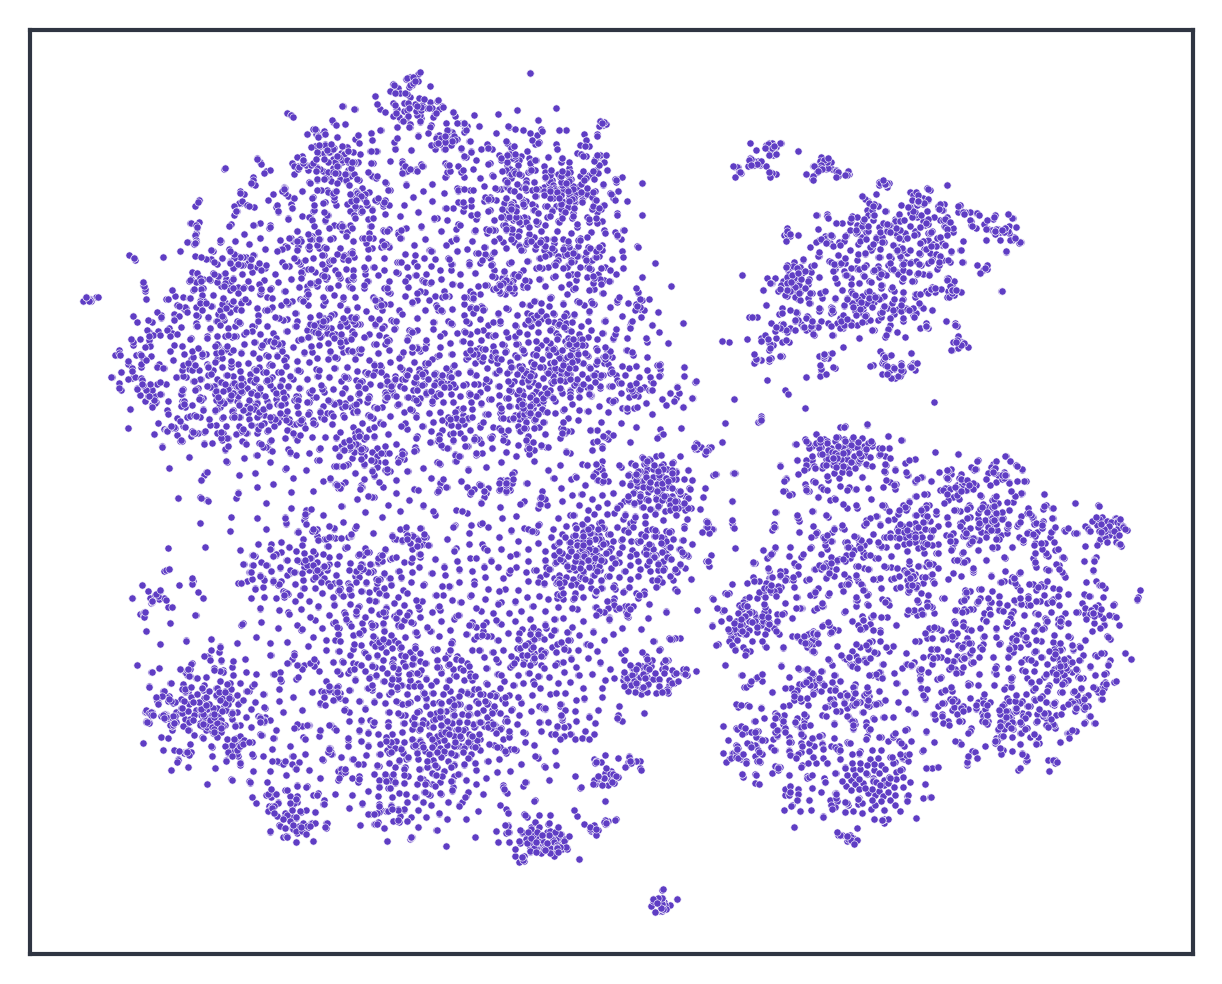

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

# 加载 .npy 文件
embeddings = np.load('draw-data/emb/bb-stsb-train.npy')

# 采样1000
# np.random.seed(42)
# idx = np.random.choice(len(embeddings), 1000, replace=False)
# embeddings = embeddings[idx]

# 使用 t-SNE 降维到 2D
tsne = TSNE(n_components=2, random_state=42)
reduced_embeddings = tsne.fit_transform(embeddings)

# 创建一个数据框来保存降维后的结果
df = pd.DataFrame(reduced_embeddings, columns=['x', 'y'])

# 绘制散点图
plt.figure(figsize=(5, 4), dpi=300)
ax = sns.scatterplot(x='x', y='y', data=df, s=3, color='#5f3dc4', alpha=1)

# 设置边框颜色和宽度
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_color('#2f3542')
    ax.spines[spine].set_linewidth(1)

# 不显示 x 和 y 轴
# ax.set_title('title', fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

# 显示图形
plt.show()